# 🛡️ Phishing URL Detection — LightGBM
**Dataset:** PhiUSIIL Phishing URL Dataset (UCI ML Repository)  
**Target:** Klasifikasi biner URL phishing (0) vs aman (1)  
**Tugas Besar APM — Sistem Informasi, Universitas Andalas 2026**

---
## Daftar Isi
1. Import Library & Konfigurasi
2. Load & Eksplorasi Dataset (EDA)
3. Preprocessing Data
   - 3.1 Cleaning (Duplikat & Missing Values)
   - 3.2 Seleksi Fitur
   - 3.3 Normalisasi (StandardScaler)
   - 3.4 Data Splitting (80/20)
4. Training Model LightGBM
5. Evaluasi Model
6. Visualisasi Hasil
7. Export Model & Artefak

---
## 1. Import Library & Konfigurasi

In [1]:
# Install dependencies jika belum ada
# !pip install lightgbm scikit-learn pandas numpy matplotlib seaborn joblib imbalanced-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import warnings
import os

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')

# Seed untuk reproducibility
SEED = 42
np.random.seed(SEED)

# Buat folder untuk menyimpan model
os.makedirs('./model', exist_ok=True)

print('✅ Library berhasil di-import')
print(f'LightGBM version: {lgb.__version__}')

✅ Library berhasil di-import
LightGBM version: 4.6.0


---
## 2. Load & Eksplorasi Dataset (EDA)

In [3]:
# ─── Load Dataset ───────────────────────────────────────────────────────────
# Sesuaikan path jika perlu
CSV_PATH = 'PhiUSIIL_Phishing_URL_Dataset.csv'

df = pd.read_csv(CSV_PATH)
print(f'Shape dataset: {df.shape}')
print(f'Jumlah kolom : {df.shape[1]}')
df.head(3)

Shape dataset: (235795, 56)
Jumlah kolom : 56


,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1


In [4]:
# ─── Info dasar ─────────────────────────────────────────────────────────────
print('=== INFO DATASET ===')
print(df.info())

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 56 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   FILENAME                    235795 non-null  object 
 1   URL                         235795 non-null  object 
 2   URLLength                   235795 non-null  int64  
 3   Domain                      235795 non-null  object 
 4   DomainLength                235795 non-null  int64  
 5   IsDomainIP                  235795 non-null  int64  
 6   TLD                         235795 non-null  object 
 7   URLSimilarityIndex          235795 non-null  float64
 8   CharContinuationRate        235795 non-null  float64
 9   TLDLegitimateProb           235795 non-null  float64
 10  URLCharProb                 235795 non-null  float64
 11  TLDLength                   235795 non-null  int64  
 12  NoOfSubDomain               235795 non-null  int64 

In [5]:
# ─── Statistik deskriptif ───────────────────────────────────────────────────
df.describe().T.style.background_gradient(cmap='Blues')

,count,mean,std,min,25%,50%,75%,max
URLLength,235795.000000,34.573095,41.314153,13.000000,23.000000,27.000000,34.000000,6097.000000
DomainLength,235795.000000,21.470396,9.150793,4.000000,16.000000,20.000000,24.000000,110.000000
IsDomainIP,235795.000000,0.002706,0.051946,0.000000,0.000000,0.000000,0.000000,1.000000
URLSimilarityIndex,235795.000000,78.430778,28.976055,0.155574,57.024793,100.000000,100.000000,100.000000
CharContinuationRate,235795.000000,0.845508,0.216632,0.000000,0.680000,1.000000,1.000000,1.000000
TLDLegitimateProb,235795.000000,0.260423,0.251628,0.000000,0.005977,0.079963,0.522907,0.522907
URLCharProb,235795.000000,0.055747,0.010587,0.001083,0.050747,0.057970,0.062875,0.090824
TLDLength,235795.000000,2.764456,0.599739,2.000000,2.000000,3.000000,3.000000,13.000000
NoOfSubDomain,235795.000000,1.164758,0.600969,0.000000,1.000000,1.000000,1.000000,10.000000
HasObfuscation,235795.000000,0.002057,0.045306,0.000000,0.000000,0.000000,0.000000,1.000000


Distribusi Label:
  Phishing(0) : 100,945 (42.8%)
  Benign  (1) : 134,850 (57.2%)


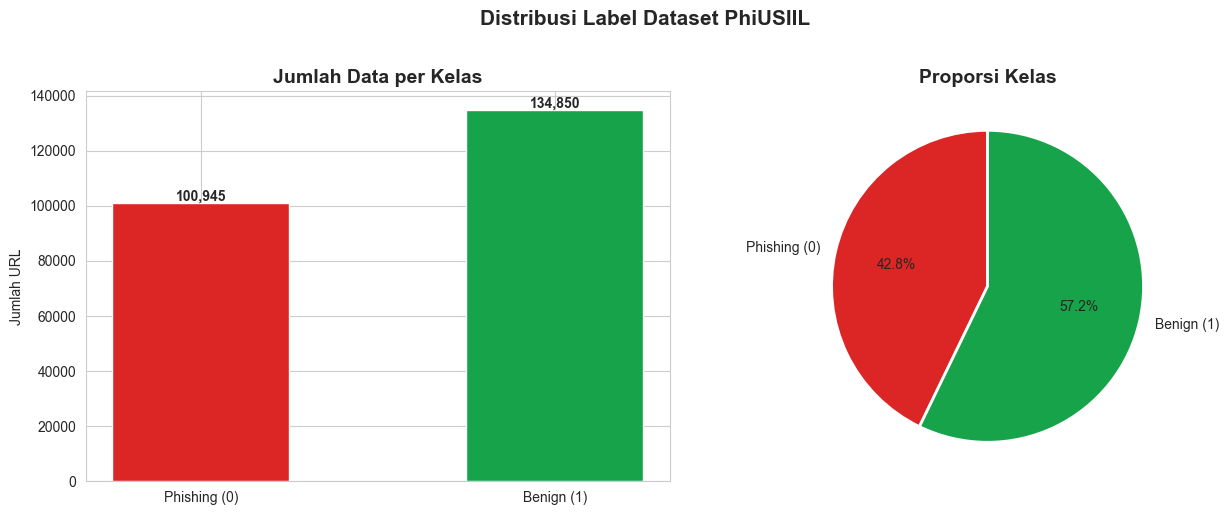

In [6]:
# ─── Distribusi label ───────────────────────────────────────────────────────
label_counts = df['label'].value_counts().sort_index()
label_pct    = df['label'].value_counts(normalize=True).sort_index() * 100

print('Distribusi Label:')
print(f'  Phishing(0) : {label_counts[0]:,} ({label_pct[0]:.1f}%)')
print(f'  Benign  (1) : {label_counts[1]:,} ({label_pct[1]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
colors = ['#DC2626', '#16A34A'] # Red for Phishing, Green for Benign
axes[0].bar(['Phishing (0)', 'Benign (1)'], label_counts.values, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Jumlah Data per Kelas', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah URL')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(
    label_counts.values,
    labels=['Phishing (0)', 'Benign (1)'],
    colors=colors, autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
axes[1].set_title('Proporsi Kelas', fontsize=14, fontweight='bold')

plt.suptitle('Distribusi Label Dataset PhiUSIIL', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('./model/eda_label_distribution.png', bbox_inches='tight', dpi=150)
plt.show()


In [7]:
# ─── Cek missing values ─────────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Pct (%)': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)

if missing_df.empty:
    print('✅ Tidak ada missing values!')
else:
    print(f'⚠️  Kolom dengan missing values:')
    display(missing_df)

print(f'\nJumlah baris duplikat: {df.duplicated().sum():,}')

✅ Tidak ada missing values!



Jumlah baris duplikat: 0


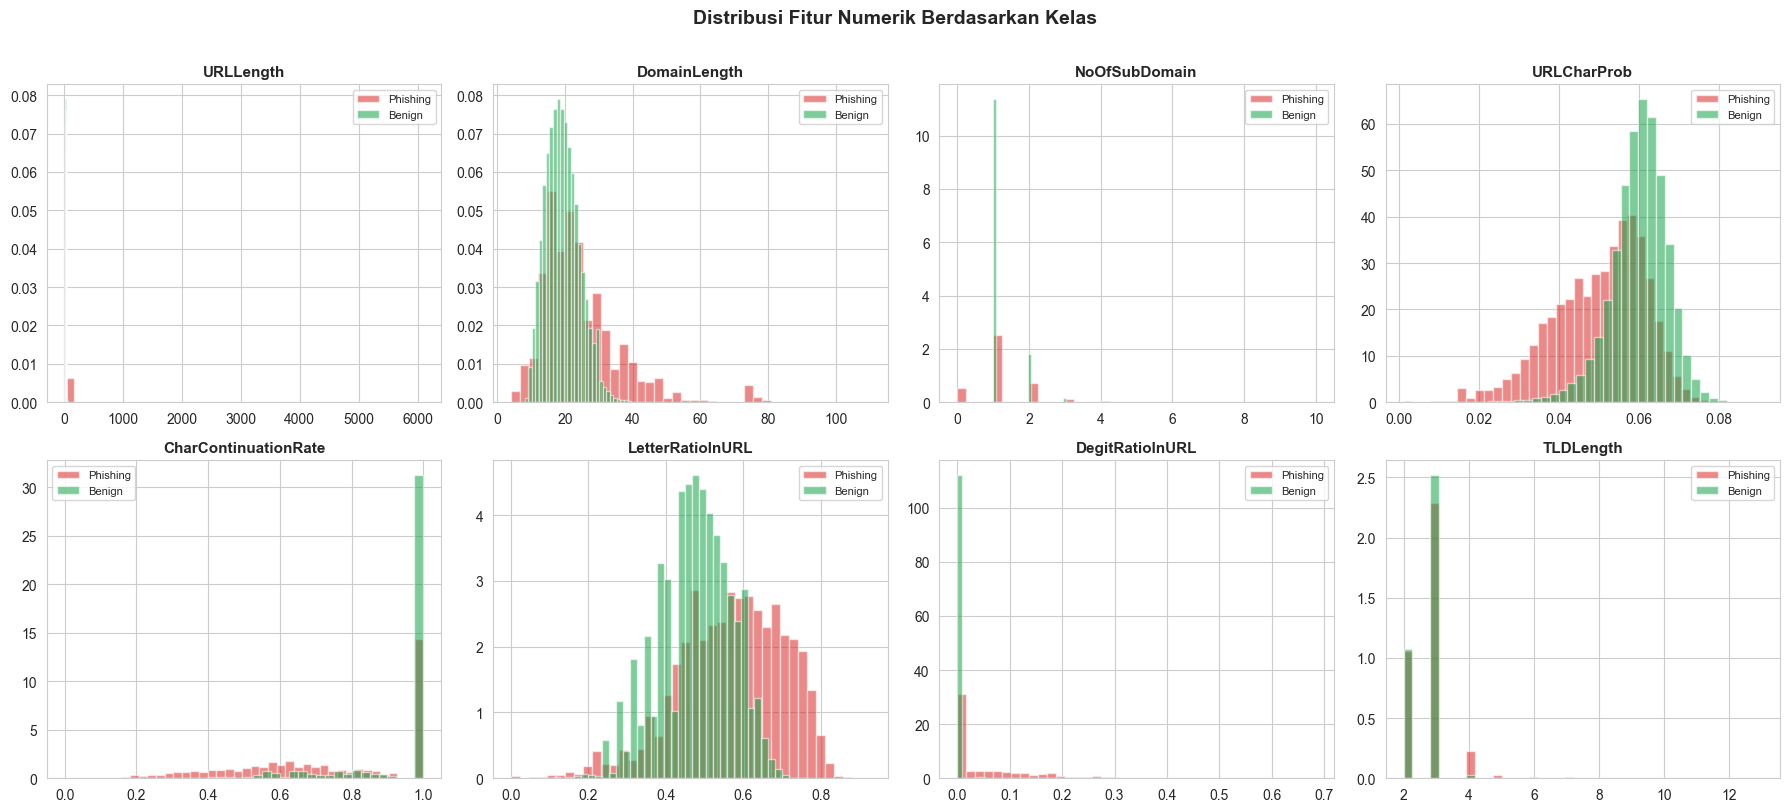

In [8]:
# ─── Distribusi beberapa fitur numerik penting ──────────────────────────────
NUMERIC_COLS = ['URLLength', 'DomainLength', 'NoOfSubDomain', 'URLCharProb',
                'CharContinuationRate', 'LetterRatioInURL', 'DegitRatioInURL', 'TLDLength']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_COLS):
    if col in df.columns:
        for label_val, color, name in [(0, '#DC2626', 'Phishing'), (1, '#16A34A', 'Benign')]:
            axes[i].hist(
                df[df['label']==label_val][col].dropna(),
                bins=40, alpha=0.55, color=color, label=name, density=True
            )
        axes[i].set_title(col, fontsize=11, fontweight='bold')
        axes[i].legend(fontsize=8)
        axes[i].set_xlabel('')

plt.suptitle('Distribusi Fitur Numerik Berdasarkan Kelas', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('./model/eda_feature_distributions.png', bbox_inches='tight', dpi=150)
plt.show()

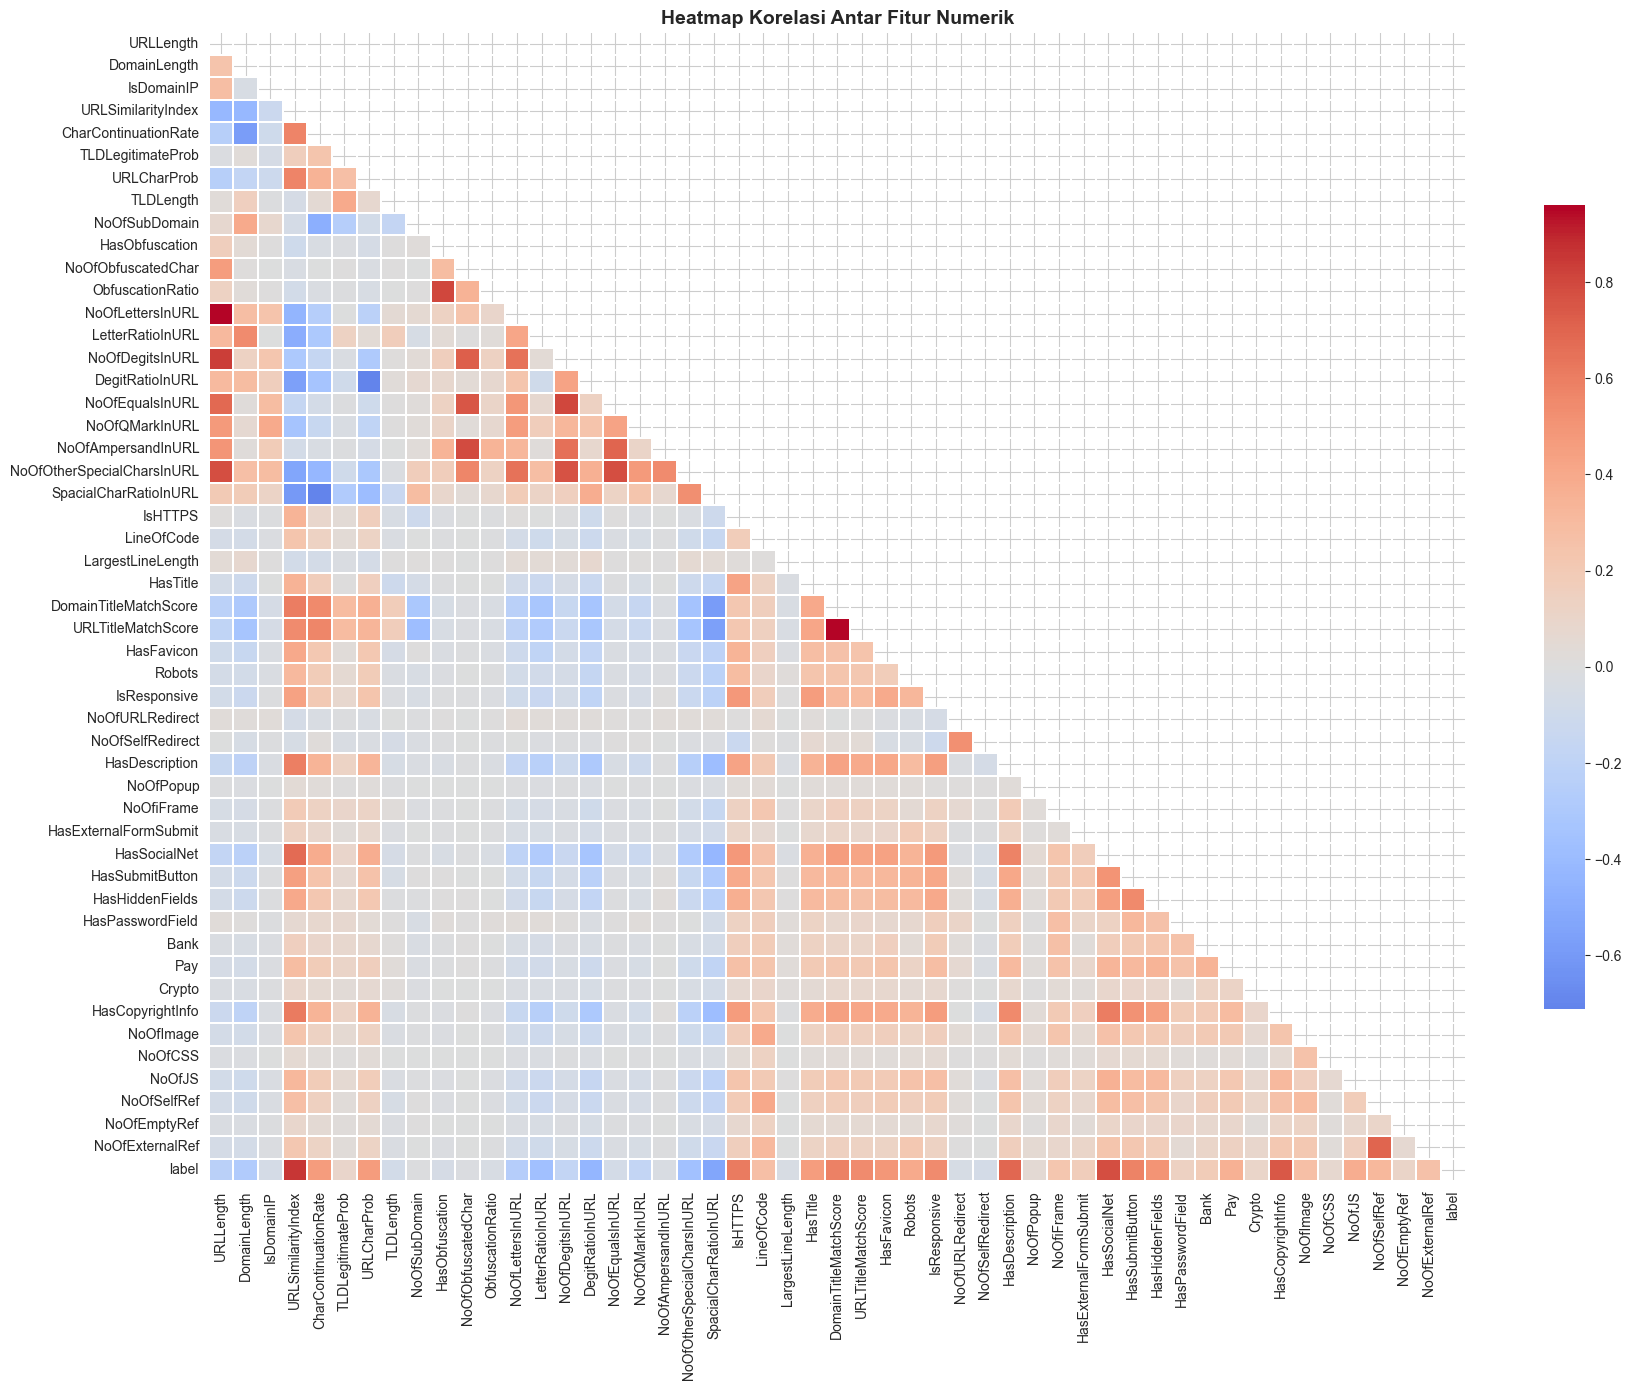

In [9]:
# ─── Heatmap korelasi (fitur numerik pilihan) ────────────────────────────────
# Kolom non-numerik dan kolom identitas yang dikecualikan
EXCLUDE_COLS = ['FILENAME', 'URL', 'Domain', 'TLD', 'Title']
num_df = df.drop(columns=EXCLUDE_COLS, errors='ignore').select_dtypes(include=[np.number])

corr = num_df.corr()

plt.figure(figsize=(18, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=False, cmap='coolwarm', center=0,
    linewidths=0.3, cbar_kws={'shrink': 0.7}
)
plt.title('Heatmap Korelasi Antar Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./model/eda_correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 3. Preprocessing Data

### 3.1 Cleaning — Hapus Duplikat & Kolom Non-Numerik

In [10]:
print(f'Shape sebelum cleaning : {df.shape}')

# Hapus duplikat
df.drop_duplicates(inplace=True)

# Hapus missing values (dataset ini relatif bersih)
df.dropna(inplace=True)

# Pisahkan fitur dan label
# Kolom yang dikecualikan: identitas, teks, dan label
DROP_COLS = ['FILENAME', 'URL', 'Domain', 'TLD', 'Title', 'label', 'URLSimilarityIndex', 'TLDLegitimateProb', 'URLCharProb']

X = df.drop(columns=DROP_COLS, errors='ignore')
y = df['label']

print(f'Shape setelah cleaning  : {df.shape}')
print(f'Jumlah fitur numerik    : {X.shape[1]}')


Shape sebelum cleaning : (235795, 56)


Shape setelah cleaning  : (235795, 56)
Jumlah fitur numerik    : 47


### 3.2 Seleksi Fitur — SelectKBest (f_classif)

In [11]:
# 🔍 SelectKBest untuk memilih fitur terbaik ━━━━━━━━━━━━━━━━
K_BEST = 40  # Pilih 40 fitur terbaik dari total fitur

# Split data train-test sebelum feature selection agar tidak ada data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

selector = SelectKBest(score_func=f_classif, k=K_BEST)
selector.fit(X_train, y_train)

# Daftar fitur terpilih
feature_mask     = selector.get_support()
selected_features= X_train.columns[feature_mask].tolist()
feature_scores   = pd.DataFrame({
    'feature': X_train.columns,
    'score'  : selector.scores_,
    'selected': feature_mask
}).sort_values('score', ascending=False)

print(f'Total fitur sebelum seleksi : {X_train.shape[1]}')
print(f'Fitur terpilih (K={K_BEST})  : {len(selected_features)}')
print(f'\nTop 10 Fitur berdasarkan F-score:')
print(feature_scores.head(10).to_string(index=False))


Total fitur sebelum seleksi : 47
Fitur terpilih (K=40)  : 40

Top 10 Fitur berdasarkan F-score:
              feature         score  selected
         HasSocialNet 300255.345370      True
     HasCopyrightInfo 232218.638386      True
       HasDescription 171980.742242      True
              IsHTTPS 111265.504410      True
DomainTitleMatchScore  97360.773689      True
      HasSubmitButton  95125.897228      True
         IsResponsive  81164.415678      True
   URLTitleMatchScore  76986.051863      True
SpacialCharRatioInURL  75147.970156      True
      HasHiddenFields  65370.682902      True


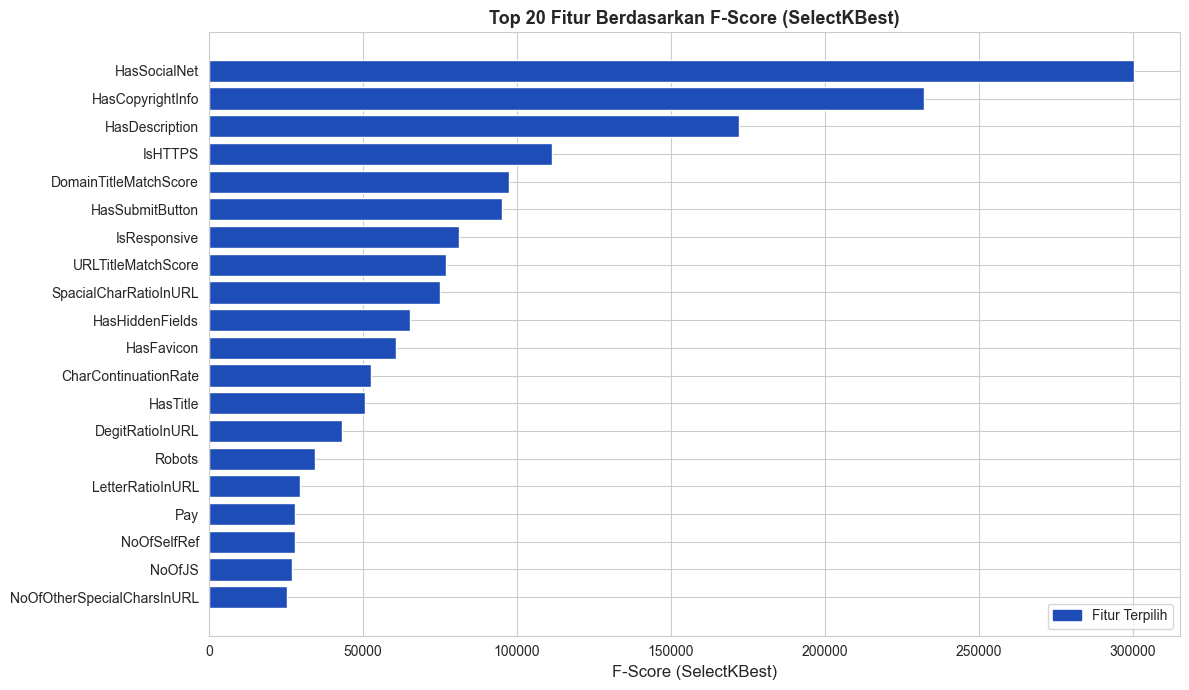

Daftar lengkap fitur terpilih:
['URLLength', 'DomainLength', 'IsDomainIP', 'CharContinuationRate', 'TLDLength', 'HasObfuscation', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'HasTitle', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfSelfRedirect', 'HasDescription', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef']


In [12]:
# ─── Visualisasi Top 20 fitur ────────────────────────────────────────────────
top20 = feature_scores.head(20)
colors_bar = ['#1E4DB7' if sel else '#D1D5DB' for sel in top20['selected']]

plt.figure(figsize=(12, 7))
bars = plt.barh(top20['feature'][::-1], top20['score'][::-1], color=colors_bar[::-1], edgecolor='white')
plt.xlabel('F-Score (SelectKBest)', fontsize=12)
plt.title('Top 20 Fitur Berdasarkan F-Score (SelectKBest)', fontsize=13, fontweight='bold')

selected_patch = mpatches.Patch(color='#1E4DB7', label='Fitur Terpilih')
plt.legend(handles=[selected_patch], loc='lower right')
plt.tight_layout()
plt.savefig('./model/feature_importance_selectkbest.png', bbox_inches='tight', dpi=150)
plt.show()

print('Daftar lengkap fitur terpilih:')
print(selected_features)

### 3.3 Normalisasi & 3.4 Data Splitting

In [13]:
# 🔍 Ambil hanya fitur terpilih dari data train & test yang sudah di-split ━━━━━
X_train = X_train[selected_features]
X_test = X_test[selected_features]

print(f'X_train : {X_train.shape}  |  X_test : {X_test.shape}')
print(f'y_train distribusi: {dict(y_train.value_counts())}')
print(f'y_test  distribusi: {dict(y_test.value_counts())}')


X_train : (188636, 40)  |  X_test : (47159, 40)
y_train distribusi: {1: 107880, 0: 80756}
y_test  distribusi: {1: 26970, 0: 20189}


In [14]:
# ─── StandardScaler (fit pada train, transform pada train & test) ────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Konversi ke DataFrame agar nama kolom tetap ada
X_train_scaled = pd.DataFrame(X_train_scaled, columns=selected_features)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=selected_features)

print('✅ Normalisasi selesai (StandardScaler)')
print(f'Mean train (contoh): {X_train_scaled.iloc[:, 0].mean():.4f} (≈0)')
print(f'Std  train (contoh): {X_train_scaled.iloc[:, 0].std():.4f} (≈1)')

✅ Normalisasi selesai (StandardScaler)


Mean train (contoh): -0.0000 (≈0)
Std  train (contoh): 1.0000 (≈1)


---
## 4. Training Model LightGBM

In [15]:
# ─── Konfigurasi LightGBM ────────────────────────────────────────────────────
lgbm_params = {
    'n_estimators'      : 500,
    'learning_rate'     : 0.05,
    'max_depth'         : 8,
    'num_leaves'        : 63,       # 2^max_depth - 1 adalah batas atas yang baik
    'subsample'         : 0.8,      # Bagging fraction
    'colsample_bytree'  : 0.8,      # Feature fraction
    'min_child_samples' : 20,
    'reg_alpha'         : 0.1,      # L1 regularization
    'reg_lambda'        : 0.1,      # L2 regularization
    'class_weight'      : 'balanced',
    'random_state'      : SEED,
    'n_jobs'            : -1,
    'verbose'           : -1,
}

print('Konfigurasi model LightGBM:')
for k, v in lgbm_params.items():
    print(f'  {k:25s}: {v}')

Konfigurasi model LightGBM:
  n_estimators             : 500
  learning_rate            : 0.05
  max_depth                : 8
  num_leaves               : 63
  subsample                : 0.8
  colsample_bytree         : 0.8
  min_child_samples        : 20
  reg_alpha                : 0.1
  reg_lambda               : 0.1
  class_weight             : balanced
  random_state             : 42
  n_jobs                   : -1
  verbose                  : -1


In [16]:
# ─── Training dengan Early Stopping ─────────────────────────────────────────
lgbm_model = lgb.LGBMClassifier(**lgbm_params)

lgbm_model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_test_scaled, y_test)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=100)
    ]
)

print(f'\n✅ Training selesai!')
print(f'Best iteration: {lgbm_model.best_iteration_}')

[100]	valid_0's binary_logloss: 0.00507196


[200]	valid_0's binary_logloss: 0.000709453


[300]	valid_0's binary_logloss: 0.000499205


[400]	valid_0's binary_logloss: 0.000450626


[500]	valid_0's binary_logloss: 0.000432917

✅ Training selesai!
Best iteration: 500


---
## 5. Evaluasi Model

In [17]:
# ─── Prediksi ────────────────────────────────────────────────────────────────
y_pred      = lgbm_model.predict(X_test_scaled)
y_pred_prob = lgbm_model.predict_proba(X_test_scaled)[:, 1]

# ─── Metrik Utama ────────────────────────────────────────────────────────────
acc  = accuracy_score (y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score   (y_test, y_pred)
f1   = f1_score       (y_test, y_pred)
auc  = roc_auc_score  (y_test, y_pred_prob)

print('=' * 45)
print('       EVALUASI MODEL LIGHTGBM')
print('=' * 45)
print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision : {prec:.4f}  ({prec*100:.2f}%)')
print(f'  Recall    : {rec:.4f}  ({rec*100:.2f}%)')
print(f'  F1-Score  : {f1:.4f}  ({f1*100:.2f}%)')
print(f'  ROC-AUC   : {auc:.4f}  ({auc*100:.2f}%)')
print('=' * 45)

print('\nClassification Report:')


       EVALUASI MODEL LIGHTGBM
  Accuracy  : 0.9999  (99.99%)
  Precision : 0.9999  (99.99%)
  Recall    : 1.0000  (100.00%)
  F1-Score  : 0.9999  (99.99%)
  ROC-AUC   : 1.0000  (100.00%)

Classification Report:


True Negative  (TN): 20,186  — Phishing diprediksi Phishing ✅
False Positive (FP): 3  — Phishing diprediksi Benign ❌
False Negative (FN): 0  — Benign diprediksi Phishing ❌
True Positive  (TP): 26,970  — Benign diprediksi Benign   ✅


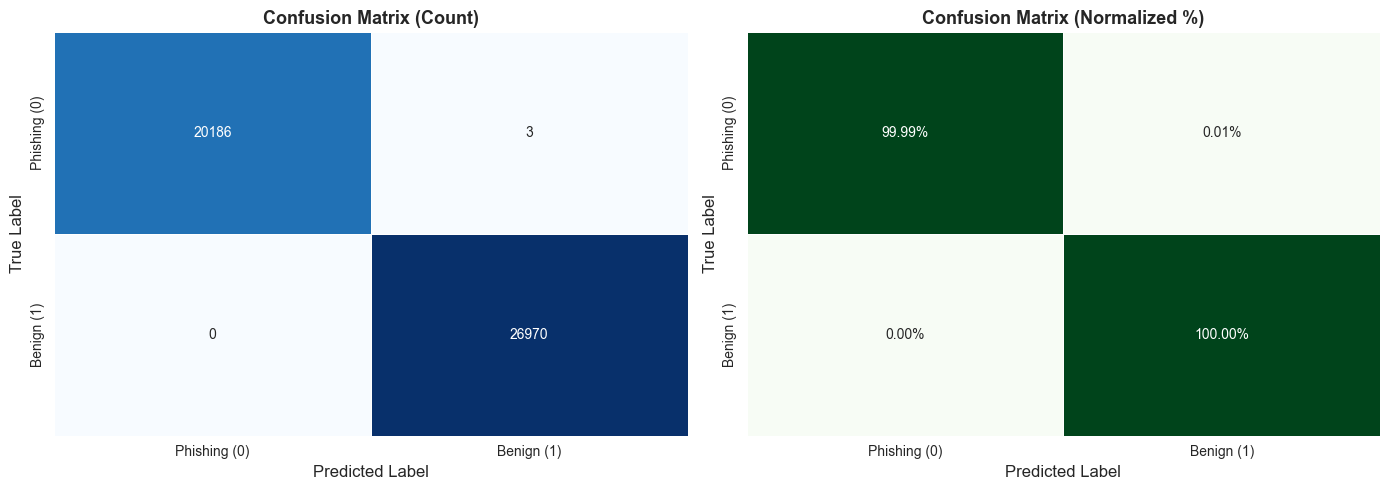

In [18]:
# ─── Confusion Matrix ────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Confusion Matrix (counts)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Phishing (0)', 'Benign (1)'],
    yticklabels=['Phishing (0)', 'Benign (1)'],
    ax=axes[0], linewidths=0.5, cbar=False
)
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_title('Confusion Matrix (Count)', fontsize=13, fontweight='bold')

# Plot 2: Confusion Matrix (normalized %)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(
    cm_norm, annot=True, fmt='.2%', cmap='Greens',
    xticklabels=['Phishing (0)', 'Benign (1)'],
    yticklabels=['Phishing (0)', 'Benign (1)'],
    ax=axes[1], linewidths=0.5, cbar=False
)
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_title('Confusion Matrix (Normalized %)', fontsize=13, fontweight='bold')

TN, FP, FN, TP = cm.ravel()
print(f'True Negative  (TN): {TN:,}  — Phishing diprediksi Phishing ✅')
print(f'False Positive (FP): {FP:,}  — Phishing diprediksi Benign ❌')
print(f'False Negative (FN): {FN:,}  — Benign diprediksi Phishing ❌')
print(f'True Positive  (TP): {TP:,}  — Benign diprediksi Benign   ✅')

plt.tight_layout()
plt.savefig('./model/confusion_matrix.png', bbox_inches='tight', dpi=150)


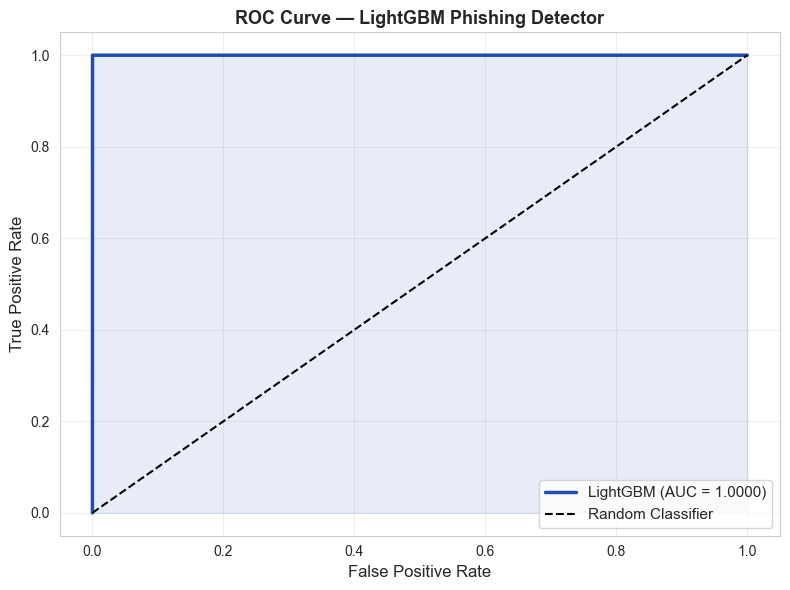

In [19]:
# ─── ROC Curve ───────────────────────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#1E4DB7', lw=2.5, label=f'LightGBM (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='#1E4DB7')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — LightGBM Phishing Detector', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('./model/roc_curve.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 6. Visualisasi Hasil

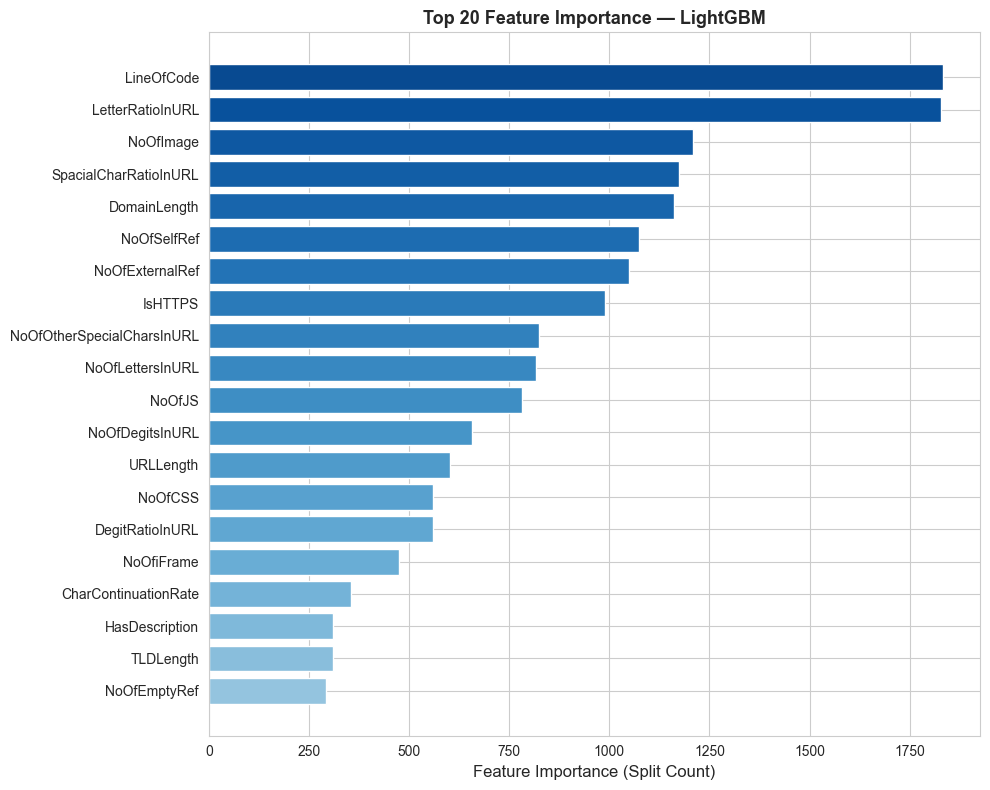

In [20]:
# ─── Feature Importance dari Model LightGBM ─────────────────────────────────
fi_df = pd.DataFrame({
    'feature'   : selected_features,
    'importance': lgbm_model.feature_importances_
}).sort_values('importance', ascending=True).tail(20)  # Top 20

plt.figure(figsize=(10, 8))
colors_fi = plt.cm.Blues(np.linspace(0.4, 0.9, len(fi_df)))
bars = plt.barh(fi_df['feature'], fi_df['importance'], color=colors_fi, edgecolor='white')
plt.xlabel('Feature Importance (Split Count)', fontsize=12)
plt.title('Top 20 Feature Importance — LightGBM', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('./model/lgbm_feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

In [21]:
# ─── Perbandingan Metrik: LightGBM vs Baseline ──────────────────────────────
print('Training model baseline untuk perbandingan...')

# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced')
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# Random Forest (100 pohon untuk kecepatan)
rf = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1, class_weight='balanced')
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

# Kompilasi hasil
comparison = {
    'Model'    : ['Logistic Regression', 'Random Forest', 'LightGBM (Kami)'],
    'Accuracy' : [accuracy_score(y_test, y_pred_lr),  accuracy_score(y_test, y_pred_rf),  acc],
    'Precision': [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_rf), prec],
    'Recall'   : [recall_score(y_test, y_pred_lr),    recall_score(y_test, y_pred_rf),    rec],
    'F1-Score' : [f1_score(y_test, y_pred_lr),        f1_score(y_test, y_pred_rf),        f1],
}
comp_df = pd.DataFrame(comparison)
print('\nPerbandingan Performa Model:')
print(comp_df.to_string(index=False))

Training model baseline untuk perbandingan...



Perbandingan Performa Model:
              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.998940   0.998925 0.999221  0.999073
      Random Forest  0.999640   0.999407 0.999963  0.999685
    LightGBM (Kami)  0.999936   0.999889 1.000000  0.999944


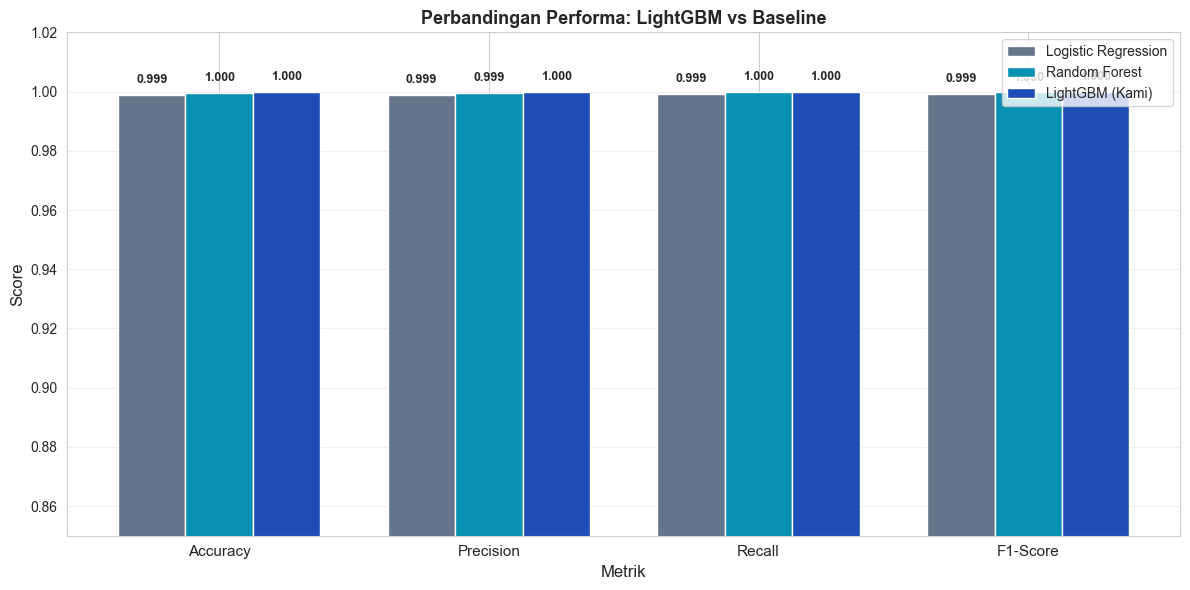

In [22]:
# ─── Visualisasi Perbandingan ────────────────────────────────────────────────
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.25
model_colors = ['#64748B', '#0891B2', '#1E4DB7']

fig, ax = plt.subplots(figsize=(12, 6))
for i, (model_name, color) in enumerate(zip(comp_df['Model'], model_colors)):
    vals = [comp_df.loc[comp_df['Model']==model_name, m].values[0] for m in metrics]
    bars = ax.bar(x + i*width, vals, width, label=model_name, color=color, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Metrik', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Perbandingan Performa: LightGBM vs Baseline', fontsize=13, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0.85, 1.02)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('./model/model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

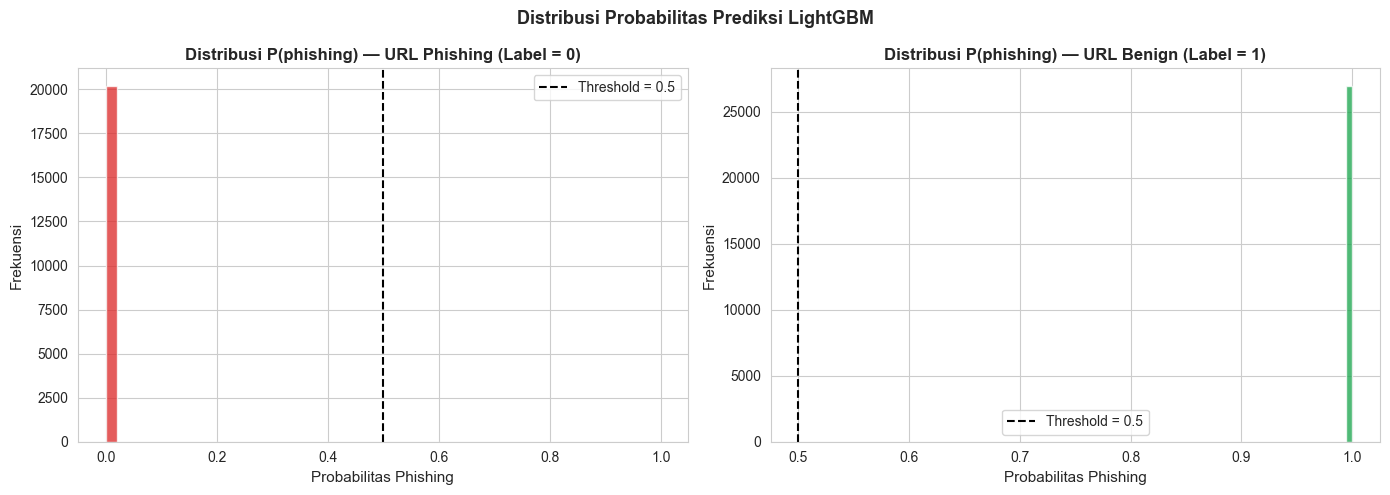

In [23]:
# ─── Distribusi Probabilitas Prediksi ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label_val, color, title in [
    (0, '#DC2626', 'URL Phishing (Label = 0)'),
    (1, '#16A34A', 'URL Benign (Label = 1)')
]:
    idx = y_test.values == label_val
    axes[label_val].hist(y_pred_prob[idx], bins=50, color=color, alpha=0.75, edgecolor='white')
    axes[label_val].axvline(x=0.5, color='black', linestyle='--', lw=1.5, label='Threshold = 0.5')
    axes[label_val].set_title(f'Distribusi P(phishing) — {title}', fontsize=12, fontweight='bold')
    axes[label_val].set_xlabel('Probabilitas Phishing', fontsize=11)
    axes[label_val].set_ylabel('Frekuensi', fontsize=11)
    axes[label_val].legend()

plt.suptitle('Distribusi Probabilitas Prediksi LightGBM', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('./model/prediction_probability_dist.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 7. Export Model & Artefak

In [24]:
# ─── Simpan model, scaler, dan daftar fitur ──────────────────────────────────
joblib.dump(lgbm_model,       './model/lgbm_model.pkl')
joblib.dump(scaler,           './model/scaler.pkl')
joblib.dump(selected_features,'./model/selected_features.pkl')

print('✅ Model dan artefak berhasil disimpan:')
print('   ./model/lgbm_model.pkl        — Model LightGBM terlatih')
print('   ./model/scaler.pkl            — StandardScaler (fit pada data train)')
print('   ./model/selected_features.pkl — Daftar 40 fitur terpilih')

✅ Model dan artefak berhasil disimpan:
   ./model/lgbm_model.pkl        — Model LightGBM terlatih
   ./model/scaler.pkl            — StandardScaler (fit pada data train)
   ./model/selected_features.pkl — Daftar 40 fitur terpilih


In [25]:
# ─── Simpan ringkasan metrik ke file teks ────────────────────────────────────
summary = f"""=== RINGKASAN EVALUASI MODEL LIGHTGBM ===
Dataset     : PhiUSIIL Phishing URL Dataset
Total Data  : {len(df):,} baris
Fitur Awal  : {X.shape[1]}
Fitur Pakai : {len(selected_features)} (SelectKBest k=40)
Train/Test  : 80% / 20%

--- Metrik (Data Test) ---
Accuracy  : {acc:.4f} ({acc*100:.2f}%)
Precision : {prec:.4f} ({prec*100:.2f}%)
Recall    : {rec:.4f} ({rec*100:.2f}%)
F1-Score  : {f1:.4f} ({f1*100:.2f}%)
ROC-AUC   : {auc:.4f} ({auc*100:.2f}%)

--- Confusion Matrix ---
TN={TN:,}  FP={FP:,}
FN={FN:,}  TP={TP:,}

--- Parameter LightGBM ---
n_estimators     : {lgbm_params['n_estimators']}
learning_rate    : {lgbm_params['learning_rate']}
max_depth        : {lgbm_params['max_depth']}
num_leaves       : {lgbm_params['num_leaves']}
best_iteration   : {lgbm_model.best_iteration_}
"""

with open('./model/evaluation_summary.txt', 'w') as f:
    f.write(summary)

print(summary)

=== RINGKASAN EVALUASI MODEL LIGHTGBM ===
Dataset     : PhiUSIIL Phishing URL Dataset
Total Data  : 235,795 baris
Fitur Awal  : 47
Fitur Pakai : 40 (SelectKBest k=40)
Train/Test  : 80% / 20%

--- Metrik (Data Test) ---
Accuracy  : 0.9999 (99.99%)
Precision : 0.9999 (99.99%)
Recall    : 1.0000 (100.00%)
F1-Score  : 0.9999 (99.99%)
ROC-AUC   : 1.0000 (100.00%)

--- Confusion Matrix ---
TN=20,186  FP=3
FN=0  TP=26,970

--- Parameter LightGBM ---
n_estimators     : 500
learning_rate    : 0.05
max_depth        : 8
num_leaves       : 63
best_iteration   : 500



In [26]:
# ─── Simpan daftar fitur ke CSV untuk referensi FastAPI ─────────────────────
pd.DataFrame({'feature': selected_features, 'order': range(len(selected_features))}).to_csv(
    './model/selected_features.csv', index=False
)
print('✅ selected_features.csv disimpan — gunakan ini sebagai referensi di feature_extractor.py')

✅ selected_features.csv disimpan — gunakan ini sebagai referensi di feature_extractor.py


In [27]:
# ─── Uji coba inferensi dengan satu contoh URL ──────────────────────────────
# Ambil satu sampel dari test set
sample_idx  = 0
sample_X    = X_test_scaled.iloc[[sample_idx]]
sample_true = y_test.iloc[sample_idx]

pred_label = lgbm_model.predict(sample_X)[0]
pred_prob  = lgbm_model.predict_proba(sample_X)[0]

print('=== CONTOH INFERENSI ===')
print(f'Label sebenarnya      : {sample_true} ({"Phishing" if sample_true==0 else "Benign"})')
print(f'Prediksi model        : {pred_label} ({"Phishing" if pred_label==0 else "Benign"})')
print(f'P(Phishing=0)         : {pred_prob[0]:.4f}')
print(f'P(Benign=1)           : {pred_prob[1]:.4f}')
print(f'Confidence            : {max(pred_prob)*100:.2f}%')
print(f'Benar?                : {"✅ Ya" if pred_label == sample_true else "❌ Tidak"}')


=== CONTOH INFERENSI ===
Label sebenarnya      : 1 (Benign)
Prediksi model        : 1 (Benign)
P(Phishing=0)         : 0.0000
P(Benign=1)           : 1.0000
Confidence            : 100.00%
Benar?                : ✅ Ya


---
## ✅ Ringkasan Tahapan

| Tahap | Keterangan | Status |
|-------|-----------|--------|
| Load Dataset | PhiUSIIL 235k baris, 54 fitur | ✅ |
| EDA | Distribusi label, heatmap korelasi | ✅ |
| Cleaning | Hapus duplikat & missing values | ✅ |
| Seleksi Fitur | SelectKBest f_classif, k=40 | ✅ |
| Normalisasi | StandardScaler fit on train | ✅ |
| Splitting | 80% train / 20% test, stratified | ✅ |
| Training LightGBM | 500 trees, early stopping | ✅ |
| Evaluasi | Accuracy, Precision, Recall, F1, AUC | ✅ |
| Perbandingan | vs Logistic Regression & Random Forest | ✅ |
| Export | lgbm_model.pkl + scaler.pkl + features.pkl | ✅ |

### File Output
```
./model/
├── lgbm_model.pkl              ← Model LightGBM terlatih
├── scaler.pkl                  ← StandardScaler
├── selected_features.pkl       ← List 40 fitur (joblib)
├── selected_features.csv       ← List 40 fitur (CSV)
├── evaluation_summary.txt      ← Ringkasan metrik
├── eda_label_distribution.png
├── eda_feature_distributions.png
├── eda_correlation_heatmap.png
├── feature_importance_selectkbest.png
├── lgbm_feature_importance.png
├── confusion_matrix.png
├── roc_curve.png
├── model_comparison.png
└── prediction_probability_dist.png
```

**Langkah selanjutnya:** Integrasikan `lgbm_model.pkl`, `scaler.pkl`, dan `selected_features.pkl` ke dalam `python-ml/app/predictor.py` untuk digunakan oleh FastAPI.